In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.shape

(891, 12)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
#because cabin 77% missing value we can drop this column
df = df.drop(columns='Cabin')

In [9]:
df.shape

(891, 11)

In [10]:
#age will we fill with median because this column will be usefull
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
#we can just drop 2 row because embarked missing value
df = df.dropna()

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
df.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 83.3 KB


In [16]:
df_cat = df[['Name', 'Sex', 'Ticket', 'Embarked']]
df_num = df.drop(columns=['Name', 'Sex', 'Ticket', 'Embarked'])

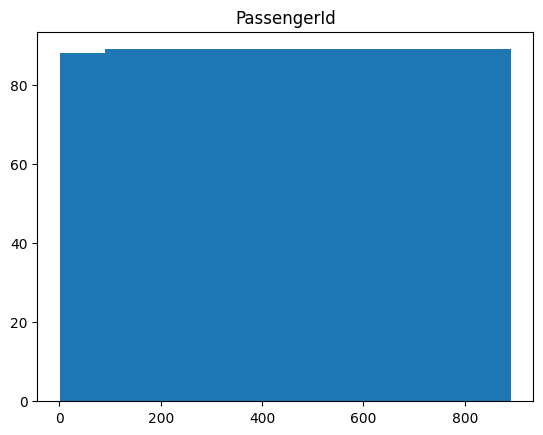

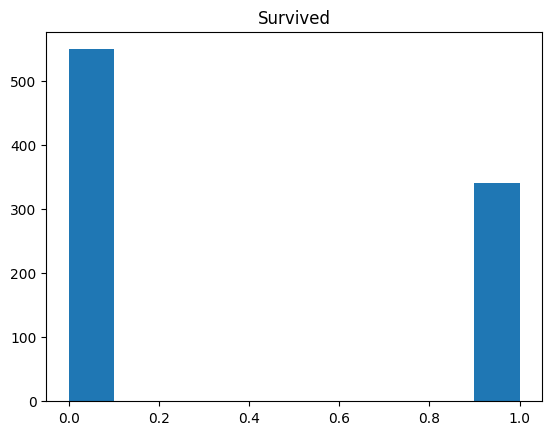

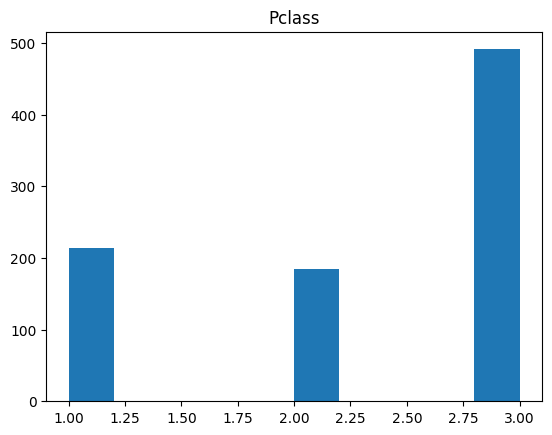

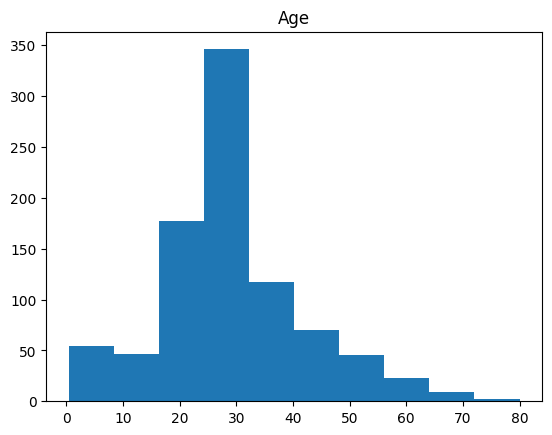

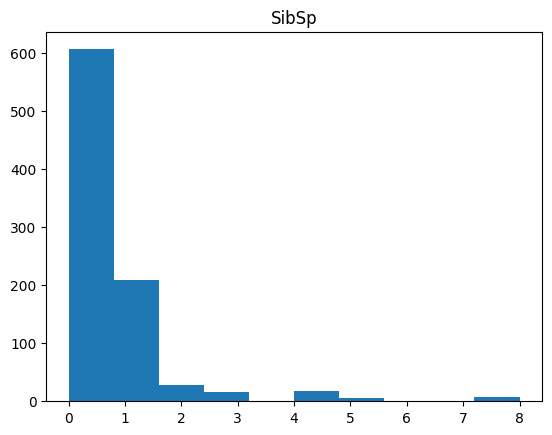

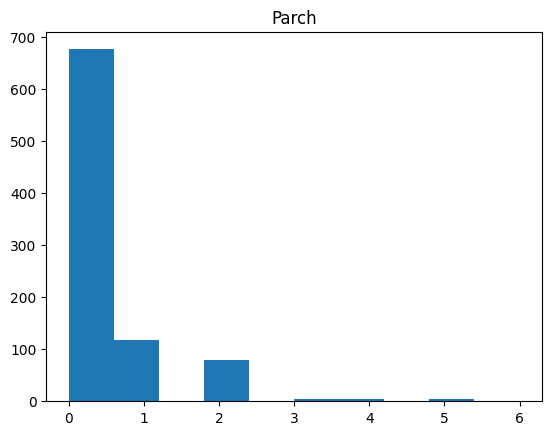

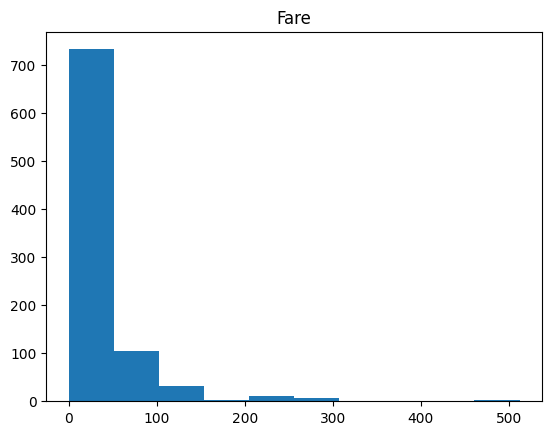

In [17]:
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005028 -0.035330  0.031319 -0.057686 -0.001657   
Survived       -0.005028  1.000000 -0.335549 -0.069822 -0.034040  0.083151   
Pclass         -0.035330 -0.335549  1.000000 -0.336512  0.081656  0.016824   
Age             0.031319 -0.069822 -0.336512  1.000000 -0.232543 -0.171485   
SibSp          -0.057686 -0.034040  0.081656 -0.232543  1.000000  0.414542   
Parch          -0.001657  0.083151  0.016824 -0.171485  0.414542  1.000000   
Fare            0.012703  0.255290 -0.548193  0.093707  0.160887  0.217532   

                 Fare  
PassengerId  0.012703  
Survived     0.255290  
Pclass      -0.548193  
Age          0.093707  
SibSp        0.160887  
Parch        0.217532  
Fare         1.000000  


<Axes: >

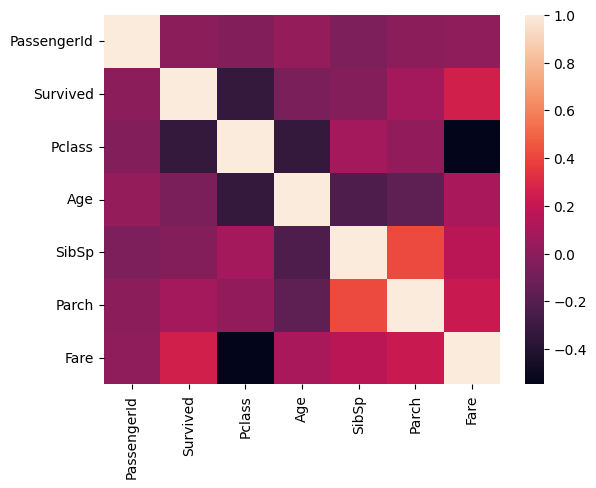

In [18]:
print(df_num.corr())
sns.heatmap(df_num.corr())

In [19]:
pd.pivot_table(df, index='Survived', values=['Age', 'SibSp', 'Parch', 'Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.028233,22.117887,0.329690,0.553734
1,28.163735,48.209498,0.467647,0.476471


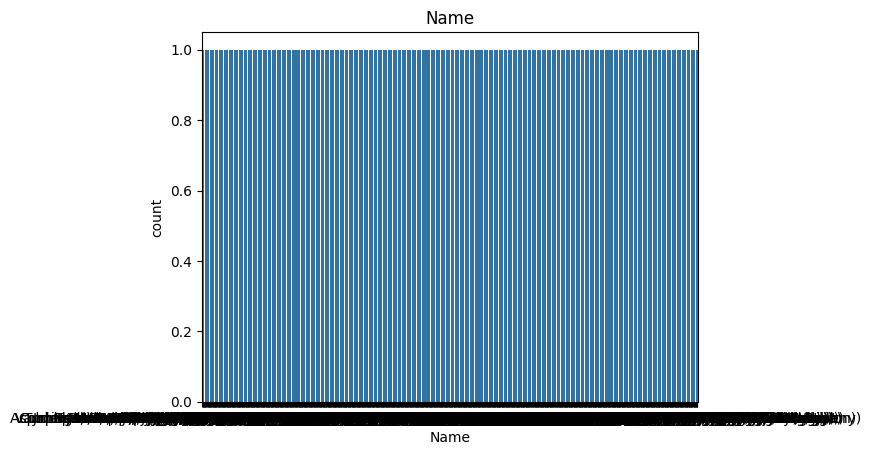

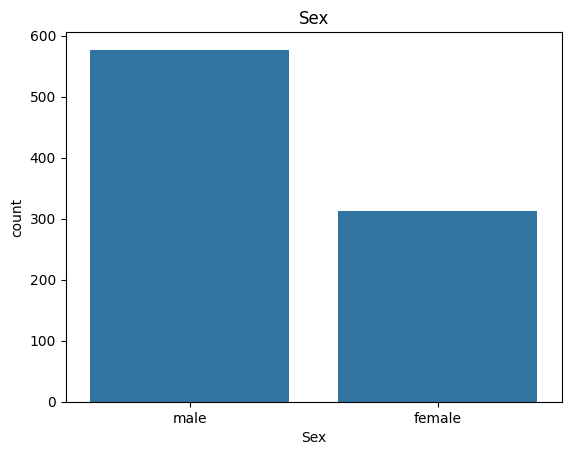

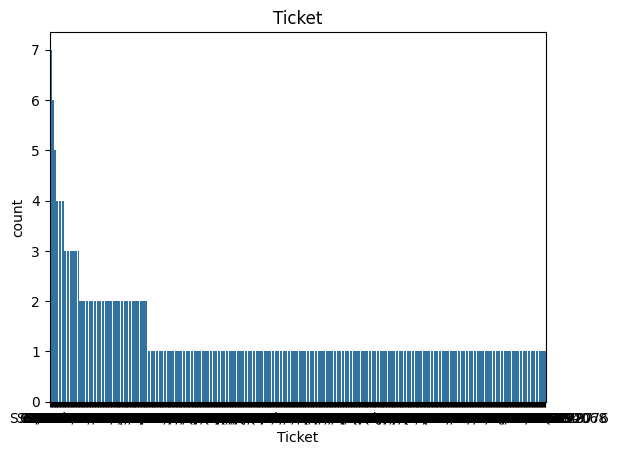

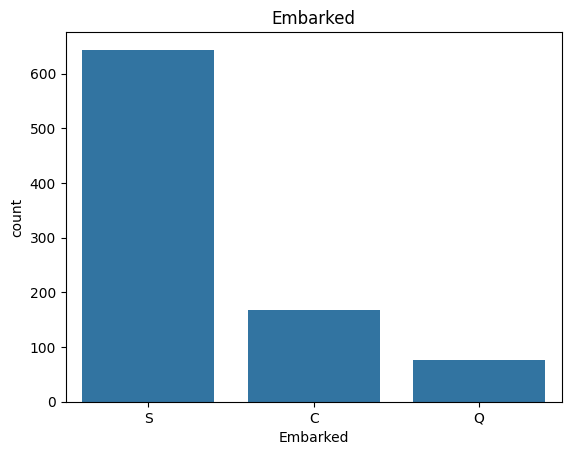

In [20]:
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index,y=df_cat[i].value_counts()).set_title(i)
    plt.show()

In [21]:
print(pd.pivot_table(df, index='Survived', columns='Pclass', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(df, index='Survived', columns='Sex', values='Ticket', aggfunc='count'))
print()
print(pd.pivot_table(df, index='Survived', columns='Embarked', values='Ticket', aggfunc='count'))

Pclass      1   2    3
Survived              
0          80  97  372
1         134  87  119

Sex       female  male
Survived              
0             81   468
1            231   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


In [24]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd


# Initialize LabelEncoder
encoder = LabelEncoder()

# Fit and transform the 'Sex' column
df['Sex_encoded'] = encoder.fit_transform(df['Sex'])

In [39]:
# Kalau ada kolom Embarked
df['Embarked_encoded'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Atau pakai get_dummies (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


#variable
y = df['Survived'] 
X = df[['Sex_encoded', 'Pclass']]

#split data into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y , train_size=0.8, random_state=0, stratify=y)

#model
lr = LogisticRegression(C=1)
lr.fit(X_train, y_train)

#score
print('Score training:{:.3f}'.format(lr.score(X_train, y_train)))
print('Score test:{:.3f}'.format(lr.score(X_test, y_test)))

Score training:0.778
Score test:0.820


In [54]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#variable
y = df['Survived'] 
X = df[['Sex_encoded', 'Pclass']]

#split data into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y , train_size=0.8)

#model
lr = LogisticRegression(C=1)
lr.fit(X_train, y_train)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

svm = SVC(random_state=0)
svm.fit(X_train, y_train)

#score
scores1 = cross_val_score(lr, X, y, cv=5)
scores2 = cross_val_score(tree, X, y, cv=5)
scores3 = cross_val_score(svm, X, y, cv=5)

print('Cross validation logistic Regression: {}'.format(scores1))
print('Cross validation scores: {:.3f}+-{:.3f}'.format(scores1.mean(), scores1.std()))
print()
print('Cross validation Decission Tree: {}'.format(scores2))
print('Cross validation scores: {:.3f}+-{:.3f}'.format(scores2.mean(), scores2.std()))
print()
print('Cross validation SVM: {}'.format(scores3))
print('Cross validation scores: {:.3f}+-{:.3f}'.format(scores3.mean(), scores3.std()))

Cross validation logistic Regression: [0.80337079 0.80337079 0.78651685 0.75280899 0.78531073]
Cross validation scores: 0.786+-0.018

Cross validation Decission Tree: [0.74719101 0.79213483 0.78651685 0.75280899 0.78531073]
Cross validation scores: 0.773+-0.019

Cross validation SVM: [0.74719101 0.79213483 0.78651685 0.75280899 0.78531073]
Cross validation scores: 0.773+-0.019
